# Workshop Notebook 2: Model Diagnostics and Architecture Augmentation

**CIROH Developer's Conference 2026 | Foundations of Machine Learning**

---

## Overview

A model that achieves NSE > 0.7 on average is promising — but the *mean* hides a lot. In this notebook we will:

1. **Diagnose** — where and when does the baseline LSTM fail?
2. **Augment with static attributes** — give the model information about basin characteristics
3. **Deepen the architecture** — add layers and explore structural modifications
4. **Compare** — side-by-side evaluation of all variants

## When should you modify a model's architecture?

Signs that structural augmentation may help:
- Systematic bias (model always over- or under-predicts in certain conditions)
- Consistent failure across seasons or flow regimes (e.g., always misses peaks)
- Large inter-basin NSE variance that correlates with a basin attribute

Signs that architecture is *not* the bottleneck:
- Training loss is much lower than validation loss -> regularization problem first
- Some basins have very few observations -> data quality problem


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cpu")

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data"
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(Path(".")))

from camels_loader import CamelsSubsetLoader, FORCING_NAMES, ATTRIBUTE_NAMES
from utils import (
    StreamflowDataset,
    masked_mse_loss,
    nse_score,
    count_params,
    train_model,
    train_model_with_attrs,
    predict_full_timeseries,
    predict_ts_with_attrs,
    make_attr_dataloaders,
)

from plots import (
    plot_seasonal_bias_and_error_magnitude,
    plot_flow_duration_curves,
    plot_nse_vs_attributes,
    plot_model_comparison,
    plot_validation_loss_comparison,
)

print("Imports OK.")


Imports OK.


In [2]:
# Reproduce the preprocessing from Notebook 1

loader = CamelsSubsetLoader(
    pickle_path=str(DATA_DIR / "camels_daymetv2_subset"),
    gage_id_path=str(DATA_DIR / "gage_id_subset.npy"),
)

TRAIN_END = "1999-09-30"
VAL_END = "2008-09-30"
SEQ_LEN = 365
STRIDE = 7

dates_idx = pd.DatetimeIndex(loader.dates)
train_mask = dates_idx <= pd.Timestamp(TRAIN_END)
val_mask = (dates_idx > pd.Timestamp(TRAIN_END)) & (dates_idx <= pd.Timestamp(VAL_END))
test_mask = dates_idx > pd.Timestamp(VAL_END)
dates_test = loader.dates[test_mask]

x_train = loader.forcings[train_mask]
x_val = loader.forcings[val_mask]
x_test = loader.forcings[test_mask]
y_train = loader.target[train_mask]
y_val = loader.target[val_mask]
y_test = loader.target[test_mask]

x_mean = x_train.mean(axis=(0, 1), keepdims=True)
x_std = x_train.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_norm = (x_train - x_mean) / x_std
x_val_norm = (x_val - x_mean) / x_std
x_test_norm = (x_test - x_mean) / x_std

y_log_mean = float(np.nanmean(np.log1p(np.clip(y_train, 0, None))))
y_log_std = float(np.nanstd(np.log1p(np.clip(y_train, 0, None))[~np.isnan(y_train)])) + 1e-8

def normalize_target(y):
    return (np.log1p(np.clip(y, 0, None)) - y_log_mean) / y_log_std

def denormalize_target(y_norm):
    return np.expm1(y_norm * y_log_std + y_log_mean)

y_train_norm = normalize_target(y_train)
y_val_norm = normalize_target(y_val)
y_test_norm = normalize_target(y_test)
obs_cfs_test = loader.target[test_mask, :, 0]
N_FEATURES = len(FORCING_NAMES)

train_loader = DataLoader(
    StreamflowDataset(x_train_norm, y_train_norm, SEQ_LEN, STRIDE), 128, shuffle=True, drop_last=True)
val_loader = DataLoader(
    StreamflowDataset(x_val_norm, y_val_norm, SEQ_LEN, STRIDE), 128)

print(loader)


CamelsSubsetLoader(basins=10, timesteps=12418, dates=1980-10-01 to 2014-09-30)


In [3]:
# Train the baseline model to use as a reference point

class LstmModel(nn.Module):
    def __init__(self, n_features, hidden_size=64, n_layers=1, dropout=0.0):
        super().__init__()
        self.input_proj = nn.Linear(n_features, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, n_layers,
                            dropout=dropout if n_layers > 1 else 0.0,
                            batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.output_proj = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = torch.relu(self.input_proj(x))
        out, _ = self.lstm(x)
        return self.output_proj(self.dropout(out)).squeeze(-1)


baseline = LstmModel(N_FEATURES, hidden_size=64, dropout=0.4).to(device)
print(f"Baseline parameters: {count_params(baseline):,}")
print("Training baseline...\n")

tl_base, vl_base = train_model(baseline, train_loader, val_loader, n_epochs=30)

pred_base_cfs = denormalize_target(predict_full_timeseries(baseline, x_test_norm, SEQ_LEN))
nse_base = {gid: nse_score(pred_base_cfs[:, i], obs_cfs_test[:, i])
            for i, gid in enumerate(loader.gage_ids)}

print("\nBaseline NSE (test):")
for gid, nse in nse_base.items():
    print(f"  {gid}: {nse:.3f}")
print(f"  Mean: {np.nanmean(list(nse_base.values())):.3f}")


Baseline parameters: 33,793
Training baseline...

  Epoch   5/30  train=0.4850  val=0.5225  lr=1.00e-03
  Epoch  10/30  train=0.4711  val=0.5225  lr=1.00e-03
  Epoch  15/30  train=0.4290  val=0.5958  lr=5.00e-04
  Epoch  20/30  train=0.4004  val=0.5690  lr=2.50e-04
  Epoch  25/30  train=0.3804  val=0.5858  lr=1.25e-04
  Epoch  30/30  train=0.3691  val=0.5762  lr=6.25e-05

Baseline NSE (test):
  2111180: -0.513
  2111500: -0.010
  2112120: 0.149
  2112360: -0.280
  2118500: 0.102
  2140991: 0.099
  3161000: 0.161
  3471500: -0.255
  3473000: -0.022
  3479000: 0.172
  Mean: -0.040



---
## 1. Model Diagnostics

Before making any architectural changes, we should understand *where* and *why* the model struggles. Good diagnostics prevent us from making changes that don't address the actual problem.

We'll examine:
- **Residual patterns** — does the error have structure (seasonal, flow-magnitude)?
- **Flow duration curves** — does the model capture the full distribution of flow?
- **Basin-level correlation** — do NSE scores correlate with basin attributes?


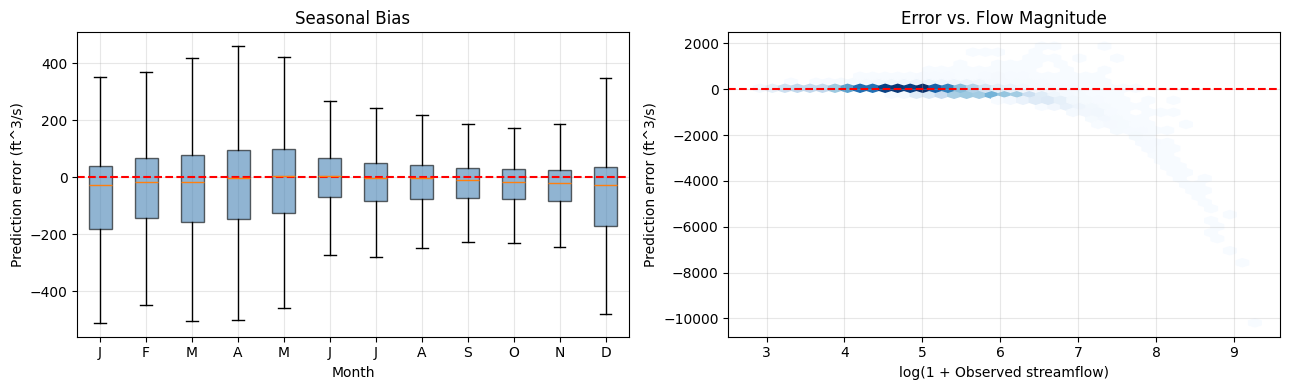

In [4]:
# Seasonal bias: residuals by calendar month
# The helper contains only plotting boilerplate; the interpretation happens in the discussion below.
plot_seasonal_bias_and_error_magnitude(dates_test, obs_cfs_test, pred_base_cfs)


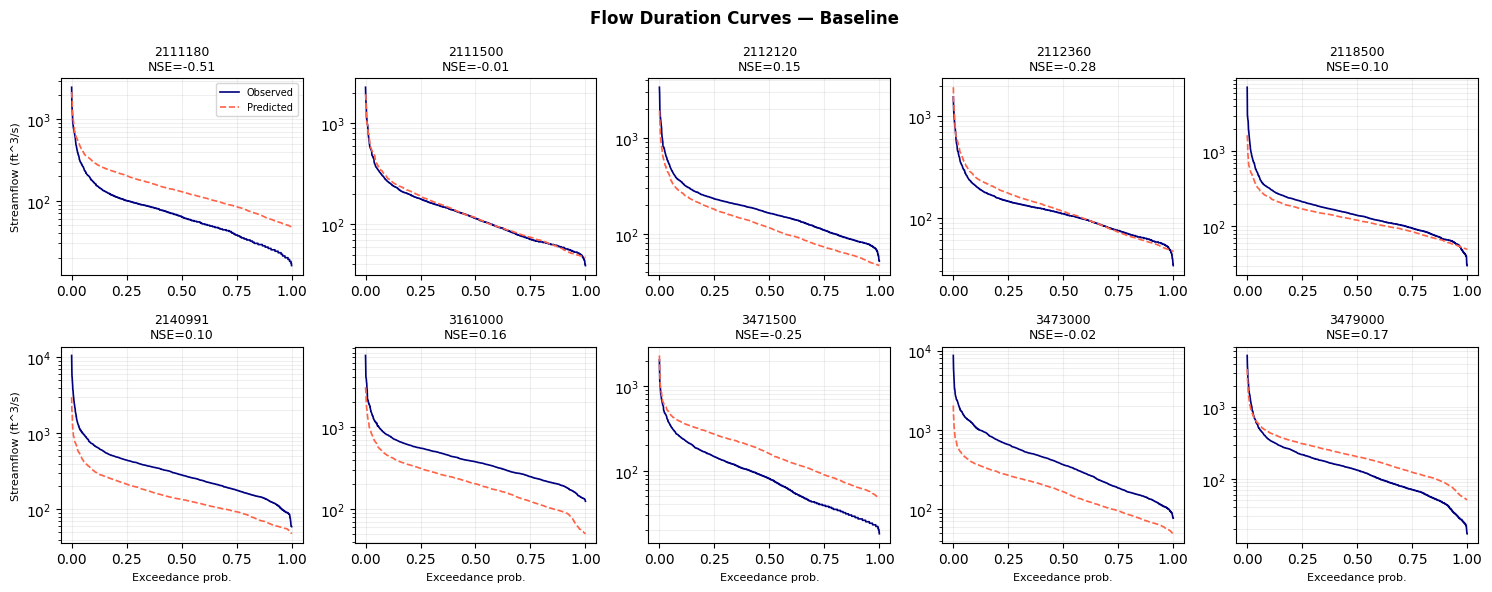

In [5]:
# Flow duration curves — exceedance probability
# A good model should match the full distribution, not just the mean.
plot_flow_duration_curves(obs_cfs_test, pred_base_cfs, loader.gage_ids, nse_base)


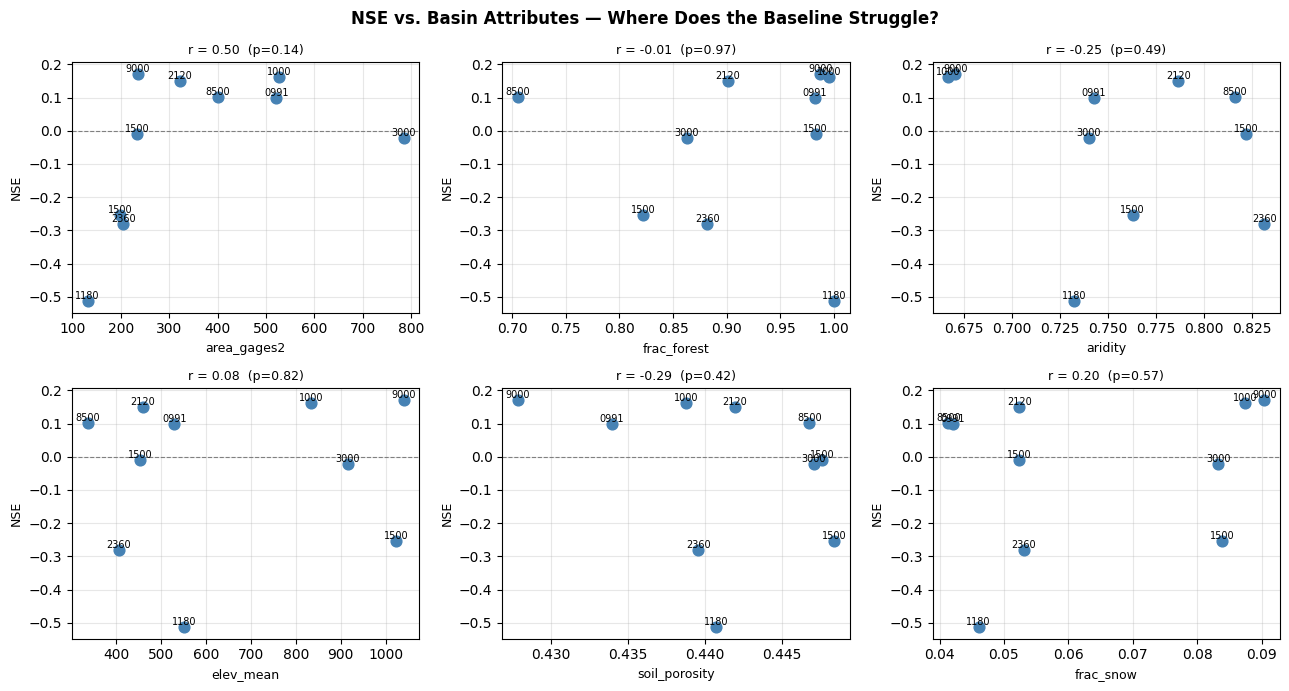

In [6]:
# Does NSE correlate with basin attributes?
# This helps identify what information the model is missing.
attr_keys = ["area_gages2", "frac_forest", "aridity", "elev_mean", "soil_porosity", "frac_snow"]
plot_nse_vs_attributes(loader.attributes, ATTRIBUTE_NAMES, loader.gage_ids, nse_base, attr_keys)


**Discussion questions:**
- Is there a seasonal pattern in the errors? What physical process might cause this?
- Does the model over- or under-predict high-flow events (left end of the FDC)?
- Which basin attribute most strongly correlates with poor NSE? What might be missing?

One common finding: models trained without **static basin attributes** struggle most on atypical basins (high aridity, high snow fraction, large area). This motivates the next section.



---
## 2. Augmentation: Static Basin Attributes

The baseline model only sees **dynamic** climate forcings — it has no knowledge of
basin physical characteristics. Two basins receiving identical precipitation can respond
very differently depending on soil permeability, slope, and vegetation.

By embedding static attributes into the model, we allow it to *condition* its
predictions on those characteristics.

### Architecture modification

```
Baseline:
  x_dynamic  (batch, seq_len, 6) -> LSTM -> prediction

With attributes:
  x_dynamic (batch, seq_len, 6)                                
  x_static (batch, 35) -> MLP -> repeat across time | cat -> LSTM  -> prediction
```


In [7]:
# Normalize static attributes
attrs_raw = loader.attributes.astype(np.float32) # (10, 35)
attrs_mean = attrs_raw.mean(axis=0, keepdims=True)
attrs_std = attrs_raw.std(axis=0, keepdims=True) + 1e-8
attrs_norm = (attrs_raw - attrs_mean) / attrs_std

N_ATTRS = attrs_norm.shape[1]
print(f"Static attributes: {N_ATTRS} features per basin")

# Dataset/DataLoader plumbing is moved to utils.py so this cell stays focused
# on the concept: adding static basin attributes as a second input.
train_loader_a, val_loader_a = make_attr_dataloaders(
    x_train_norm, y_train_norm,
    x_val_norm, y_val_norm,
    attrs_norm,
    SEQ_LEN, STRIDE,
    batch_size=128,
)

x_dyn, x_stat, y_b = next(iter(train_loader_a))
print(f"x_dynamic: {tuple(x_dyn.shape)} (batch, seq_len, forcings)")
print(f"x_static: {tuple(x_stat.shape)} (batch, n_attrs)")
print(f"y: {tuple(y_b.shape)} (batch, seq_len)")


Static attributes: 35 features per basin
x_dynamic: (128, 365, 6) (batch, seq_len, forcings)
x_static: (128, 35) (batch, n_attrs)
y: (128, 365) (batch, seq_len)


In [8]:
class LstmWithAttrs(nn.Module):
    """LSTM conditioned on static basin attributes.

    The attribute vector is encoded into an embedding and concatenated with the
    dynamic forcings at every timestep, enabling basin-specific behaviour.

    Parameters
    ----------
    n_features : number of dynamic forcing variables
    n_attrs : number of static basin attributes
    hidden_size : LSTM hidden units
    attr_embed : dimension to project attributes to before concatenation
    dropout : dropout probability
    """

    def __init__(self, n_features: int, n_attrs: int,
                 hidden_size: int = 64, attr_embed: int = 32,
                 dropout: float = 0.0):
        super().__init__()
        self.attr_encoder = nn.Sequential(
            nn.Linear(n_attrs, attr_embed),
            nn.Tanh(),
        )
        self.input_proj = nn.Linear(n_features + attr_embed, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.output_proj = nn.Linear(hidden_size, 1)

    def forward(self, x_dyn: torch.Tensor, x_stat: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x_dyn : (batch, seq_len, n_features)
        x_stat : (batch, n_attrs)

        Returns
        -------
        (batch, seq_len)
        """
        attr_emb = self.attr_encoder(x_stat)
        attr_emb = attr_emb.unsqueeze(1).expand(-1, x_dyn.size(1), -1)
        x = torch.relu(self.input_proj(torch.cat([x_dyn, attr_emb], dim=-1)))
        out, _ = self.lstm(x)
        return self.output_proj(self.dropout(out)).squeeze(-1)


model_attrs = LstmWithAttrs(
    n_features=N_FEATURES, n_attrs=N_ATTRS,
    hidden_size=64, attr_embed=32, dropout=0.4
).to(device)

print(f"LstmWithAttrs parameters: {count_params(model_attrs):,}")
print("Training...\n")

tl_attrs, vl_attrs = train_model_with_attrs(
    model_attrs, train_loader_a, val_loader_a, n_epochs=30
)

pred_attrs_cfs = denormalize_target(
    predict_ts_with_attrs(model_attrs, x_test_norm, attrs_norm, SEQ_LEN)
)
nse_attrs = {gid: nse_score(pred_attrs_cfs[:, i], obs_cfs_test[:, i])
             for i, gid in enumerate(loader.gage_ids)}

print("\nNSE — Baseline vs. +Attributes:")
print(f"  {'Gage ID':>10s}  {'Baseline':>10s}  {'+Attrs':>10s}  {'Δ NSE':>8s}")
for gid in loader.gage_ids:
    delta = nse_attrs[gid] - nse_base[gid]
    print(f"  {gid:>10d}  {nse_base[gid]:10.3f}  {nse_attrs[gid]:10.3f}  {delta:+8.3f}")
print(f"  {'Mean':>10s}  {np.nanmean(list(nse_base.values())):10.3f}"
      f"  {np.nanmean(list(nse_attrs.values())):10.3f}"
      f"  {np.nanmean(list(nse_attrs.values())) - np.nanmean(list(nse_base.values())):+8.3f}")


LstmWithAttrs parameters: 36,993
Training...

  Epoch   5/30  train=0.1429  val=0.1997  lr=1.00e-03
  Epoch  10/30  train=0.1302  val=0.1997  lr=1.00e-03
  Epoch  15/30  train=0.1181  val=0.1830  lr=5.00e-04
  Epoch  20/30  train=0.1117  val=0.1870  lr=5.00e-04
  Epoch  25/30  train=0.1068  val=0.1822  lr=2.50e-04
  Epoch  30/30  train=0.1044  val=0.1798  lr=1.25e-04

NSE — Baseline vs. +Attributes:
     Gage ID    Baseline      +Attrs     Δ NSE
     2111180      -0.513       0.127    +0.641
     2111500      -0.010       0.174    +0.184
     2112120       0.149       0.163    +0.013
     2112360      -0.280       0.111    +0.391
     2118500       0.102       0.096    -0.006
     2140991       0.099       0.296    +0.198
     3161000       0.161       0.374    +0.213
     3471500      -0.255       0.291    +0.546
     3473000      -0.022       0.496    +0.519
     3479000       0.172       0.143    -0.028
        Mean      -0.040       0.227    +0.267



---
## 3. Architecture Modifications: Depth and Convolutional Encoders

Two more structural levers:

### Deeper LSTM

Stacking multiple LSTM layers allows each layer to learn a different level of temporal abstraction — short-term runoff dynamics in layer 1, seasonal soil moisture in layer 2, and so on. Depth is only beneficial when the task genuinely has hierarchical temporal structure and when there's enough data to train the extra parameters.

### Causal convolution front-end

Replacing the linear encoder with 1D **causal convolutions** lets the model explicitly aggregate local temporal context (e.g., a 7-day precipitation event) before the LSTM processes the sequence. "Causal" means each output only depends on *past* inputs — no future leakage.

```
Input (batch, seq_len, features)
 │
 ▼  ConstantPad1d (left-pad, causal)
 ▼  Conv1d -> ReLU     looks at kernel_size consecutive days
 ▼  Conv1d -> ReLU     stacks another level of local context
 │
 ▼  LSTM -> Linear -> output
```


In [9]:
class DeepLstmModel(nn.Module):
    """Two-layer stacked LSTM with inter-layer dropout."""

    def __init__(self, n_features: int, hidden_size: int = 64,
                 n_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        self.input_proj = nn.Linear(n_features, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, n_layers,
                            dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.output_proj = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = torch.relu(self.input_proj(x))
        out, _ = self.lstm(x)
        return self.output_proj(self.dropout(out)).squeeze(-1)


class CausalConvLstmModel(nn.Module):
    """Causal convolution encoder followed by a single-layer LSTM."""

    def __init__(self, n_features: int, hidden_size: int = 64,
                 kernel_size: int = 7, dropout: float = 0.3):
        super().__init__()
        self.pad = nn.ConstantPad1d((kernel_size - 1, 0), 0.0)
        self.conv1 = nn.Conv1d(n_features, hidden_size, kernel_size)
        self.pad2 = nn.ConstantPad1d((kernel_size - 1, 0), 0.0)
        self.conv2 = nn.Conv1d(hidden_size, hidden_size, kernel_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.output_proj = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)                      # (batch, channels, seq_len)
        x = torch.relu(self.conv1(self.pad(x)))
        x = torch.relu(self.conv2(self.pad2(x)))
        x = x.permute(0, 2, 1)                      # (batch, seq_len, hidden)
        out, _ = self.lstm(x)
        return self.output_proj(self.dropout(out)).squeeze(-1)


m1 = DeepLstmModel(N_FEATURES, 64, 2, 0.3).to(device)
m2 = CausalConvLstmModel(N_FEATURES, 64, 7, 0.3).to(device)
print(f"DeepLstmModel       (2-layer LSTM) : {count_params(m1):,} params")
print(f"CausalConvLstmModel (conv + LSTM)  : {count_params(m2):,} params")


DeepLstmModel       (2-layer LSTM) : 67,073 params
CausalConvLstmModel (conv + LSTM)  : 64,833 params


In [10]:
print("=== Training DeepLstmModel ===")
model_deep = DeepLstmModel(N_FEATURES, hidden_size=64, n_layers=2, dropout=0.3).to(device)
tl_deep, vl_deep = train_model(model_deep, train_loader, val_loader, n_epochs=30, verbose=False)
pred_deep_cfs = denormalize_target(predict_full_timeseries(model_deep, x_test_norm, SEQ_LEN))
nse_deep = {gid: nse_score(pred_deep_cfs[:, i], obs_cfs_test[:, i])
            for i, gid in enumerate(loader.gage_ids)}
print(f"  Mean NSE: {np.nanmean(list(nse_deep.values())):.3f}\n")

print("=== Training CausalConvLstmModel ===")
model_conv = CausalConvLstmModel(N_FEATURES, hidden_size=64, kernel_size=7, dropout=0.3).to(device)
tl_conv, vl_conv = train_model(model_conv, train_loader, val_loader, n_epochs=30, verbose=False)
pred_conv_cfs = denormalize_target(predict_full_timeseries(model_conv, x_test_norm, SEQ_LEN))
nse_conv = {gid: nse_score(pred_conv_cfs[:, i], obs_cfs_test[:, i])
            for i, gid in enumerate(loader.gage_ids)}
print(f"  Mean NSE: {np.nanmean(list(nse_conv.values())):.3f}")


=== Training DeepLstmModel ===
  Mean NSE: -0.051

=== Training CausalConvLstmModel ===
  Mean NSE: -0.118


> **Exercise** — Add your own modification.
>
> Ideas to try:
> - **Larger kernel** — change `kernel_size` in `CausalConvLstmModel` to 14 or 30
> - **Residual connection** — add the input back to the LSTM output: `out = lstm_out + input_proj(x)`
> - **Combine attributes + deep** — modify `LstmWithAttrs` to use 2 LSTM layers
> - **Highway LSTM** — add a gating mechanism on the skip connection around the LSTM



---
## 4. Model Comparison

| Model | Key feature | Expected benefit |
|-------|-------------|-----------------|
| **Baseline** | hidden=64, 1 layer | Reference point |
| **+Attributes** | Static basin embeddings | Better inter-basin generalization |
| **DeepLSTM** | 2 stacked LSTM layers | Hierarchical temporal features |
| **ConvLSTM** | Causal conv encoder + LSTM | Explicit local pattern extraction |


In [11]:
all_models = {
    "Baseline": nse_base,
    "+Attributes": nse_attrs,
    "DeepLSTM": nse_deep,
    "ConvLSTM": nse_conv,
}

df_nse = pd.DataFrame(all_models, index=loader.gage_ids)
df_nse.index.name = "Gage ID"
df_nse.loc["Mean"] = df_nse.mean()
df_nse.loc["Median"] = df_nse.iloc[:-1].median()

df_nse.round(3).style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1)


,Baseline,+Attributes,DeepLSTM,ConvLSTM
Gage ID,,,,
2111180,-0.513000,0.127000,-0.379000,-0.829000
2111500,-0.010000,0.174000,0.017000,-0.122000
2112120,0.149000,0.163000,0.063000,0.071000
2112360,-0.280000,0.111000,-0.215000,-0.319000
2118500,0.102000,0.096000,0.067000,0.089000
2140991,0.099000,0.296000,0.091000,0.085000
3161000,0.161000,0.374000,0.174000,0.141000
3471500,-0.255000,0.291000,-0.507000,-0.310000
3473000,-0.022000,0.496000,0.057000,0.001000


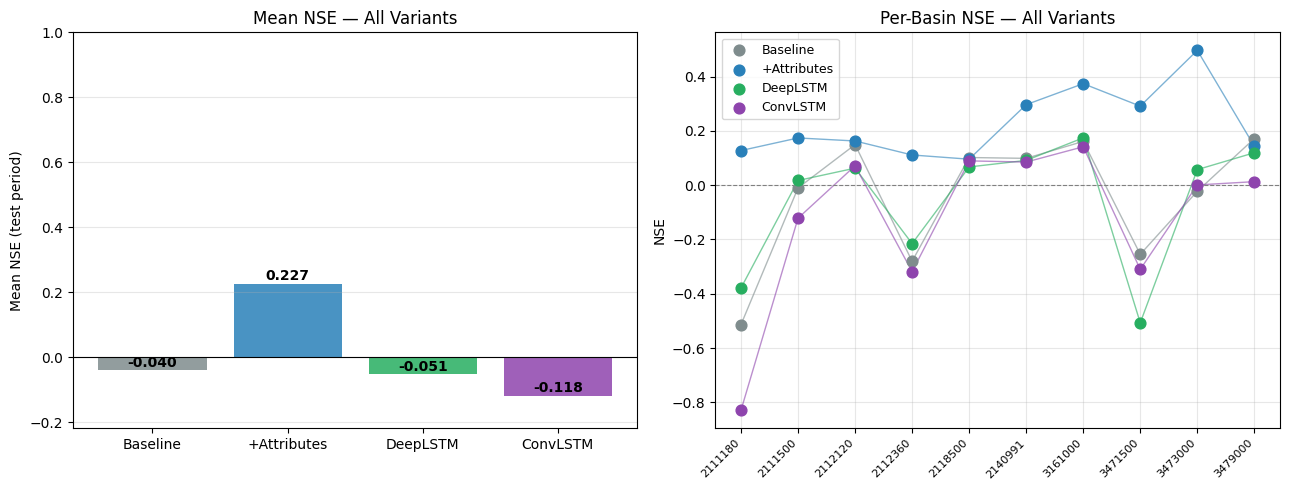

In [12]:
plot_model_comparison(all_models, loader.gage_ids, save_path="model_comparison.png")


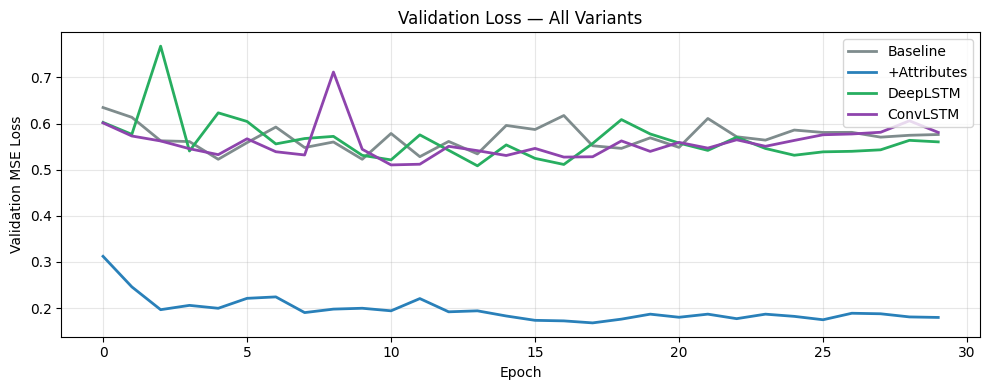

In [13]:
# Validation loss curves for all variants
lc_data = [
    ("Baseline", vl_base, "#7f8c8d"),
    ("+Attributes", vl_attrs, "#2980b9"),
    ("DeepLSTM", vl_deep, "#27ae60"),
    ("ConvLSTM", vl_conv, "#8e44ad"),
]

plot_validation_loss_comparison(lc_data)



---
## Workshop Summary

Over these two notebooks you have:

1. **Explored** the CAMELS hydrometeorological dataset
2. **Preprocessed** raw time series — temporal splits, normalization, sequence windowing
3. **Built** an LSTM from scratch with `nn.Module`
4. **Trained** with backpropagation, masked loss, and gradient clipping
5. **Evaluated** with Nash-Sutcliffe Efficiency, hydrographs, scatter diagnostics, and flow duration curves
6. **Diagnosed** underfitting, overfitting, and seasonal bias
7. **Engineered features** by adding temporal and seasonal predictors to improve input representation
8. **Augmented** models with static attributes, deeper LSTM structures, and causal convolution encoders


---
### What to explore next

- **More basins** — CAMELS has 671 basins; scale up and see how NSE generalizes
- **More features** — add soil moisture indices or snow water equivalent as forcings
- **Transformer** — replace the LSTM with a multi-head self-attention block
- **Differentiable parameter learning** — combine an LSTM with a physics-based model
- **Uncertainty quantification** — use MC Dropout or ensembles to estimate prediction intervals
